# Logistic regression


# Import the relevant libraries

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib inline

# Single

In [34]:
raw_data = pd.read_csv("data/2.01. Admittance.csv")
raw_data.head()

,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No


In [35]:
# Replace all No entries with 0, and all Yes entries with 1
data = raw_data.copy()
data["Admitted"] = data["Admitted"].map({"Yes": 1, "No": 0})
data.head()

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0


- Let's examine the independent and dependent variables.
- Logistic regression is fundamentally a model designed for binary dependent variables.

In [36]:
# Create the dependent and independent variables
y = data["Admitted"]
x1 = data["SAT"]

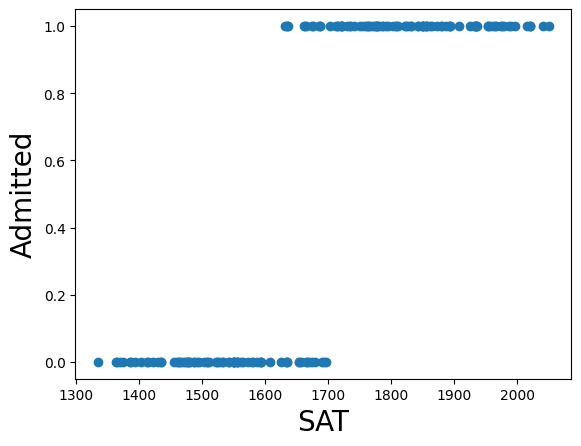

In [37]:
# Create a scatter plot of x1 (SAT, no constant) and y (Admitted)
plt.scatter(x1, y)
# Don't forget to label your axes!
plt.xlabel("SAT", fontsize=20)
plt.ylabel("Admitted", fontsize=20)
plt.show()

## Linear Regression 

Plot with a regression line

Let's try using linear regression on data with a binary target variable and see what happens.

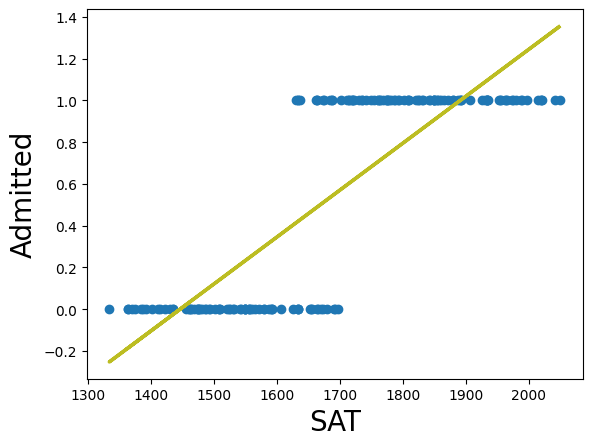

In [38]:
reg = LinearRegression()
X = x1.values.reshape(-1, 1)
reg.fit(X, y)

# Create a scatter plot
plt.scatter(x1, y, color="C0")
# Plot the regression line. The coefficients are coming from results_lin.params
y_hat = reg.coef_ * X + reg.intercept_
plt.plot(x1, y_hat, lw=2.5, color="C8")
plt.xlabel("SAT", fontsize=20)
plt.ylabel("Admitted", fontsize=20)
plt.show()

## logistic regression

In [39]:
lreg = LogisticRegression(solver="liblinear", C=100).fit(X, y)

### Preventing Overfitting Using Regularization

The parameter `C` in `LogisticRegression` controls the strength of `regularization`.

`Regularization` helps control the complexity of a model by penalizing large weights (coefficients) during training.

#### L1 Regularization (Lasso)
Tends to keep only the most important features by forcing some coefficients to become exactly zero (useful for feature selection).

#### L2 Regularization (Ridge)
The default. It discourages large weights by shrinking less important ones closer to zero, but not exactly zero.

* The penalty parameter in LogisticRegression is set to `L2` by default but can be changed to `L1`.
* Regularization helps reduce multicollinearity (when features are highly correlated).
* Regularization helps prevent overfitting by simplifying the model.
* The C parameter controls the amount of regularization:
* A smaller value of C means stronger regularization.
* Stronger regularization simplifies the model and helps prevent overfitting.


In [40]:
print(lreg.intercept_, lreg.coef_)

[-30.55733617] [[0.01842716]]


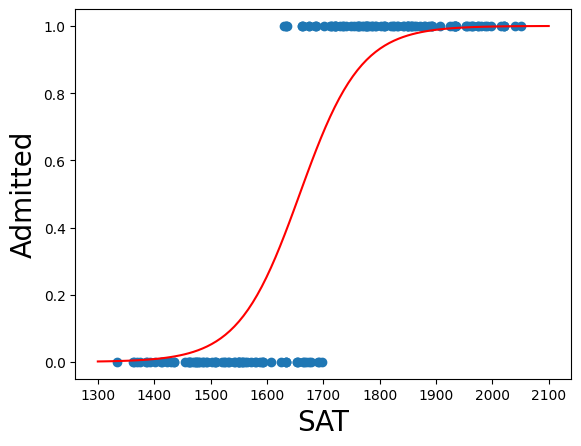

In [41]:
xx = np.linspace(1300, 2100, 100)
mu = 1.0 / (1 + np.exp(-lreg.coef_[0][0] * xx - lreg.intercept_[0]))

plt.scatter(x1, y, color="C0")
plt.xlabel("SAT", fontsize=20)
plt.ylabel("Admitted", fontsize=20)
plt.plot(xx, mu, "r")
plt.show()

### 🔍 Logistic Regression and Odds

Logistic Regression is a classification model that is based on **odds** and more precisely, on **log-odds**.

1. **Probability**  
   For example, if the probability of an event occurring is 0.8 (or 80%), then:

2. **Odds**  
   Odds represent the ratio of the probability that the event occurs to the probability that it does not occur:

   $$
   \text{odds} = \frac{p}{1 - p}
   $$

   Example: 

   $$
   \frac{0.8}{0.2} = 4
   $$

   meaning the event is 4 times more likely to happen than not.

3. **Logit Function (Log-Odds)**  
   Logistic Regression models the **log of the odds** as a linear combination of input features:

   $$
   \log\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n
   $$

4. **Converting Log-Odds to Probability**  
   The model output (log-odds) is converted back to probability using the **sigmoid function**:

   $$
   p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}
   $$

In summary, logistic regression predicts the log-odds of an event, which is then transformed into a probability between 0 and 1 using the sigmoid function.


### Predict

In [42]:
lreg.predict([[1520]])

array([0])

In [43]:
lreg.predict([[1980]])

array([1])

### Evaluating the Classification Performance of the Model

> A confusion matrix is a table that shows whether the predicted categories from the model match the actual categories in the data.

In [44]:
from sklearn.metrics import confusion_matrix

pred = lreg.predict(X)

confusion = confusion_matrix(y, pred)

print("Confusion Matrix: \n{}".format(confusion))

Confusion Matrix: 
[[66  8]
 [ 4 90]]


### Evaluating the Accuracy of a Classifier

- LinearRegression().score() → R²
- LogisticRegression().score() → Accuracy

In [45]:
lreg.score(X, y)

0.9285714285714286